In [6]:
pip install uv

   ---------------------------------------- 0.0/21.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/21.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/21.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/21.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/21.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/21.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/21.4 MB ? eta -:--:--
    --------------------------------------- 0.5/21.4 MB 339.1 kB/s eta 0:01:02
   - -------------------------------------- 0.8/21.4 MB 482.4 kB/s eta 0:00:43
   - -------------------------------------- 0.8/21.4 MB 482.4 kB/s eta 0:00:43
   - -------------------------------------- 1.0/21.4 MB 562.6 kB/s eta 0:00:37
   - -------------------------------------- 1.0/21.4 MB 562.6 kB/s eta 0:00:37
   - -------------------------------------- 1.0/21.4 MB 562.6 kB/s eta 0:00:37
   - -------------------------------

In [1]:
import pandas as pd

df = pd.read_parquet("2024_10k_data.parquet")
df.info()
df.head()
df.describe(include='all')
df.duplicated().sum()
df.isna().sum().sort_values(ascending=False)
df.describe(percentiles=[.01,.25,.5,.75,.99])

# Summary: SIC codes classify companies by industry (first two numbers are industry, second two numbers are sub-industry)
# *Data is 496 S&P 500 companies
# *std of 1845 indicates that there is wide diversity of firms
# *The 27-75 pc ranges indicate that most firms fall between manufacturing, retail and finance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cik               496 non-null    object
 1   company_name      496 non-null    object
 2   sic_code          496 non-null    int64 
 3   item1             496 non-null    object
 4   item1a            496 non-null    object
 5   date_filed        496 non-null    object
 6   period_of_report  496 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.3+ KB


,sic_code
count,496.000000
mean,4833.366935
std,1845.780300
min,100.000000
1%,1311.000000
25%,3570.000000
50%,4911.000000
75%,6331.000000
99%,8120.500000
max,8741.000000


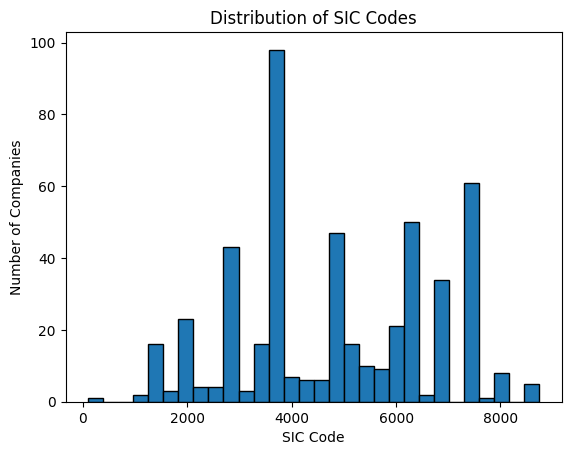

In [2]:
import matplotlib.pyplot as plt

plt.hist(df['sic_code'], bins=30, edgecolor='black')
plt.title("Distribution of SIC Codes")
plt.xlabel("SIC Code")
plt.ylabel("Number of Companies")
plt.show()

# Note: SIC of around ~3900 indicates a particular clustering of "Miscellaneous Manufacturing Industries". See also the 6 other spikes,
#

# Spike region (approx.)	Major SIC grouping	Industry sector
# 1000–1499	Mining & Quarrying	Energy, natural resources, oil extraction
# 2000–2799	Manufacturing (food, textiles, paper, chemicals)	Traditional goods production
# 3000–3999	Manufacturing (metal, machinery, electronics, misc.)	Heavy industry, durable goods
# 3900	Miscellaneous manufacturing	Catch-all category for diversified firms
# 4800–4999	Transportation, Communication, Utilities	Telecoms, power, water utilities
# 6000–6799	Finance, Insurance, Real Estate	Banks, investment firms, insurance
# 7300–8900	Services	Tech, business, healthcare, education, entertainment

In [32]:
# Decent start.
# We will now add a YAML file with ESG discourse, hardcode the path to our .parquet file, and set data directories
# NOTE: Analysis is based on 2024 values. Final analysis will cover the period 2013-2024 and be more complex.

from pathlib import Path

RAW_PARQUET_PATH = Path("2024_10k_data.parquet")  
LEXICON_PATH = Path("ESG_Lexicon.yml")           
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
PROC_DIR = DATA_DIR / "processed"
FIG_DIR = BASE_DIR / "figures"

for p in (DATA_DIR, PROC_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

print(f" Parquet: {RAW_PARQUET_PATH}")
print(f" Lexicon: {LEXICON_PATH}")



 Parquet: 2024_10k_data.parquet
 Lexicon: ESG_Lexicon.yml


In [1]:
# Import data, warnings, and RNG. Initialise Polars for dataframe manipulation.
# Install with: uv pip addnumpy polars pandas matplotlib

import re, unicodedata, warnings, random
import numpy as np
warnings.filterwarnings("ignore")

try:
    import polars as pl
    USING_POLARS = True
except Exception:
    import pandas as pd
    USING_POLARS = False

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.grid": True,
    "axes.edgecolor": "#444",
    "axes.labelcolor": "#222",
    "font.size": 11
})

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


ModuleNotFoundError: No module named 'numpy'

In [15]:
# Deploy helper functions to normalise text, split words, hash paragraphs etc.
def normalize_text(s: str) -> str:
    if not isinstance(s, str): return ""
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", " ", s.replace("\u00A0", " ")).strip()
    return s

def basic_clean(s: str) -> str:
    s = s.lower()
    s = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", s)
    s = s.replace("-\n", "")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def safe_len_words(s: str) -> int:
    return len(s.split()) if isinstance(s, str) else 0

def paragraph_hash(s: str) -> str:
    import hashlib
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

PARA_SPLIT = re.compile(r"\n\s*\n|(?<=\.)\s{2,}")
def split_paragraphs(s: str):
    if not isinstance(s, str) or not s.strip(): return []
    parts = re.split(PARA_SPLIT, s)
    return [p.strip() for p in parts if p.strip()]



In [16]:
# Load .parquet file and perform mapping with either Polars or normal dataframes, depending on if it works properly

if USING_POLARS:
    df = pl.read_parquet(str(RAW_PARQUET_PATH))
    if "filing_date" in df.columns:
        df = df.with_columns(pl.col("filing_date").str.strptime(pl.Date, strict=False))
        df = df.with_columns(pl.col("filing_date").dt.year().alias("filing_year"))
    for col in ("text","section","company","ticker"):
        if col in df.columns:
            df = df.with_columns(pl.col(col).cast(pl.Utf8).map_elements(normalize_text).alias(col))
    if "text" in df.columns:
        df = df.with_columns(pl.col("text").map_elements(safe_len_words).alias("word_count"))
    print(df.shape, df.columns)
else:
    df = pd.read_parquet(RAW_PARQUET_PATH)
    if "filing_date" in df.columns:
        df["filing_date"] = pd.to_datetime(df["filing_date"], errors="coerce")
        df["filing_year"] = df["filing_date"].dt.year
    for col in ("text","section","company","ticker"):
        if col in df.columns:
            df[col] = df[col].astype(str).map(normalize_text)
    if "text" in df.columns:
        df["word_count"] = df["text"].map(safe_len_words)
    print(df.shape, list(df.columns))


(496, 7) ['cik', 'company_name', 'sic_code', 'item1', 'item1a', 'date_filed', 'period_of_report']


In [23]:
# Housekeeping: Combine item1, item1a into a single text field for NLP

df["text_raw"] = (
    df[["item1", "item1a"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.strip()
)

# Clean empty rows if both are blank
df = df[df["text_raw"].str.len() > 0].reset_index(drop=True)

print(f"Combined text field created ({len(df)} records).")
print(df.columns)


Combined text field created (487 records).
Index(['cik', 'company_name', 'sic_code', 'item1', 'item1a', 'date_filed',
       'period_of_report', 'text_raw'],
      dtype='object')


In [30]:
# Detect paragraphs repeated 3+ times across the same CIK (boilerplate)
# and create a cleaned version of the text with those paragraphs removed.

TEXT_COL = "text_raw"  # Unified text field

if USING_POLARS:
    sample = df.sample(n=min(5000, df.height), seed=SEED) if df.height > 5000 else df
    rows = []
    for r in sample.iter_rows(named=True):
        for p in split_paragraphs(r.get(TEXT_COL, "")):
            rows.append({"cik": r.get("cik"), "p_hash": paragraph_hash(p)})
    paras = pl.DataFrame(rows) if rows else pl.DataFrame({"p_hash": []})
    if paras.height:
        counts = paras.groupby(["cik", "p_hash"]).agg(pl.count().alias("n"))
        common = set(counts.filter(pl.col("n") >= 3)["p_hash"].to_list())
    else:
        common = set()

    def remove_boilerplate(text):
        if not isinstance(text, str):
            return ""
        kept = [p for p in split_paragraphs(text) if paragraph_hash(p) not in common]
        return " ".join(kept)

    df = df.with_columns([
        # Flag any filing containing boilerplate
        pl.col(TEXT_COL).map_elements(
            lambda s: any(paragraph_hash(p) in common for p in split_paragraphs(s))
        ).alias("boilerplate_flag"),
        # Remove boilerplate paragraphs
        pl.col(TEXT_COL).map_elements(remove_boilerplate).alias("text_no_boilerplate")
    ])

else:
    from collections import defaultdict
    sample = df.sample(n=min(5000, len(df)), random_state=SEED) if len(df) > 5000 else df
    map_counts = defaultdict(int)
    for _, row in sample.iterrows():
        for p in split_paragraphs(row.get(TEXT_COL, "")):
            map_counts[(row.get("cik"), paragraph_hash(p))] += 1
    common = {h for (c, h), n in map_counts.items() if n >= 3}

    def has_common(s):
        return any(paragraph_hash(p) in common for p in split_paragraphs(s))

    def remove_boilerplate(s):
        if not isinstance(s, str):
            return ""
        kept = [p for p in split_paragraphs(s) if paragraph_hash(p) not in common]
        return " ".join(kept)

    df["boilerplate_flag"] = df[TEXT_COL].map(has_common)
    df["text_no_boilerplate"] = df[TEXT_COL].map(remove_boilerplate)

print(f" Boilerplate detection done. Found {df['boilerplate_flag'].sum()} filings with repeated text.")

# Display all filings flagged as containing boilerplate text
boiler_df = df[df["boilerplate_flag"] == True].copy()

# Show key metadata first
display(
    boiler_df[
        ["cik", "company_name", "date_filed", "period_of_report"]
    ].reset_index(drop=True)
)

# Optional: preview the first few characters of both versions
for i, row in boiler_df.head(8).iterrows():
    print(f"\n{'='*80}")
    print(f"CIK: {row['cik']} | {row['company_name']} | Filed: {row['date_filed']}")
    print(f"{'-'*80}\nORIGINAL TEXT (first 400 chars):\n{row['text_raw'][:400]}")
    print(f"\nCLEANED TEXT (boilerplate removed, first 400 chars):\n{row['text_no_boilerplate'][:400]}")


# Conclusion: 8 companies have boilerplate which is repeated 3 times. 



 Boilerplate detection done. Found 8 filings with repeated text.


,cik,company_name,date_filed,period_of_report
0,0001300514,LAS VEGAS SANDS CORP,2024-02-07,2023-12-31
1,0001141391,Mastercard Inc,2024-02-13,2023-12-31
2,0001137774,PRUDENTIAL FINANCIAL INC,2024-02-21,2023-12-31
3,0001811074,Texas Pacific Land Corp,2024-02-21,2023-12-31
4,0000065984,ENTERGY CORP /DE/,2024-02-23,2023-12-31
5,0000004904,AMERICAN ELECTRIC POWER CO INC,2024-02-26,2023-12-31
6,0001039684,ONEOK INC /NEW/,2024-02-27,2023-12-31
7,0001692819,Vistra Corp.,2024-02-29,2023-12-31



CIK: 0001300514 | LAS VEGAS SANDS CORP | Filed: 2024-02-07
--------------------------------------------------------------------------------
ORIGINAL TEXT (first 400 chars):
ITEM 1. —
BUSINESS
Our Company
Las Vegas Sands Corp. ("LVSC," or together with its subsidiaries "we" or the "Company") is the leading global developer and operator of destination properties ("Integrated Resorts") that feature premium accommodations, world-class gaming, entertainment and retail malls, convention and exhibition facilities, celebrity chef restaurants and other amenities.
We currently

CLEANED TEXT (boilerplate removed, first 400 chars):
ITEM 1. —
BUSINESS
Our Company
Las Vegas Sands Corp. ("LVSC," or together with its subsidiaries "we" or the "Company") is the leading global developer and operator of destination properties ("Integrated Resorts") that feature premium accommodations, world-class gaming, entertainment and retail malls, convention and exhibition facilities, celebrity chef restaurants and 

In [22]:
print(df.columns)


Index(['cik', 'company_name', 'sic_code', 'item1', 'item1a', 'date_filed',
       'period_of_report'],
      dtype='object')


In [40]:
print(df.text_raw)

0      ITEM 1.  BUSINESS\nOVERVIEW\nAdobe is a global...
1      ITEM  1.    Business\nGeneral\nWe are a global...
2      Item 1.    Business\nUnited Rentals is the lar...
3      Item 1.  Business.\nAll references in this rep...
4      Item 1. Business\nHISTORY AND ORGANIZATION\nHi...
                             ...                        
482    Item 1.  Business\nGeneral Description of Busi...
483    ITEM 1. Business\nWe are a global technology l...
484    Item 1.     Business\nCompany and Segment Over...
485    Item 1.\nBusiness\nOverview\nAgilent Technolog...
486    ITEM 1.BUSINESS\nOverview\nWe are a global tec...
Name: text_raw, Length: 487, dtype: object


In [ ]:
# Install once if not yet done
# !uv pip install -U fastembed

import yaml, re
import numpy as np
from fastembed import TextEmbedding

with open("ESG_Lexicon.yml", "r", encoding="utf-8") as f:
    LEX = yaml.safe_load(f)

print("Lexicon categories loaded:", list(LEX.keys()))

def rate_per_k(text, patterns):
    wc = max(1, safe_len_words(text))
    hits = sum(len(re.findall(p, text, flags=re.I)) for p in patterns)
    return 1000.0 * hits / wc

TEXT_COL = "text_raw"

if USING_POLARS:
    df = df.with_columns([
        pl.col(TEXT_COL).map_elements(lambda t: rate_per_k(t, LEX.get("E", []))).alias("kw_rate_E"),
        pl.col(TEXT_COL).map_elements(lambda t: rate_per_k(t, LEX.get("S", []))).alias("kw_rate_S"),
        pl.col(TEXT_COL).map_elements(lambda t: rate_per_k(t, LEX.get("G", []))).alias("kw_rate_G")
    ])
else:
    df["kw_rate_E"] = df[TEXT_COL].map(lambda t: rate_per_k(t, LEX.get("E", [])))
    df["kw_rate_S"] = df[TEXT_COL].map(lambda t: rate_per_k(t, LEX.get("S", [])))
    df["kw_rate_G"] = df[TEXT_COL].map(lambda t: rate_per_k(t, LEX.get("G", [])))

print(" ESG keyword rates computed from YAML Lexicon.")
print(df[["kw_rate_E", "kw_rate_S", "kw_rate_G"]].head())

def clean_seed(phrases):
    cleaned = []
    for p in phrases:
        p = re.sub(r"\\b", "", p)
        p = re.sub(r"[\\?\\*\\+\\(\\)\\|]", " ", p)
        p = re.sub(r"\s+", " ", p).strip()
        cleaned.append(p)
    return list(set(cleaned))

E_seed_phrases = clean_seed(LEX.get("E", []))
S_seed_phrases = clean_seed(LEX.get("S", []))
G_seed_phrases = clean_seed(LEX.get("G", []))

print(f"\nE (Environmental): {E_seed_phrases[:5]} ...")
print(f"S (Social): {S_seed_phrases[:5]} ...")
print(f"G (Governance): {G_seed_phrases[:5]} ...")

# --- Embedding Model (FastEmbed) ---
model = TextEmbedding("BAAI/bge-small-en-v1.5")

texts = df[TEXT_COL].to_list() if USING_POLARS else df[TEXT_COL].tolist()
emb = np.array(list(model.embed(texts, batch_size=16)))

E_seed = np.array(list(model.embed(E_seed_phrases)))
S_seed = np.array(list(model.embed(S_seed_phrases)))
G_seed = np.array(list(model.embed(G_seed_phrases)))

def sim_to_seed(embs, seed):
    sims = np.dot(embs, seed.T)
    return sims.max(axis=1)

embed_E = sim_to_seed(emb, E_seed)
embed_S = sim_to_seed(emb, S_seed)
embed_G = sim_to_seed(emb, G_seed)

if USING_POLARS:
    df = df.with_columns([
        pl.Series("embed_E", embed_E),
        pl.Series("embed_S", embed_S),
        pl.Series("embed_G", embed_G)
    ])
else:
    df["embed_E"] = embed_E
    df["embed_S"] = embed_S
    df["embed_G"] = embed_G

print("\n✅ ESG embeddings computed using FastEmbed (no Torch).")
print(df[["embed_E", "embed_S", "embed_G"]].head())


ModuleNotFoundError: No module named 'fastembed'

In [4]:
import sys
print(sys.version)


3.13.8 (tags/v3.13.8:a15ae61, Oct  7 2025, 12:34:25) [MSC v.1944 64 bit (AMD64)]


In [2]:
# Finally, we try to visualise the data

import matplotlib.pyplot as plt
import pandas as pd

dfp = df.to_pandas() if USING_POLARS else df.copy()

pivot = dfp.pivot_table(index="sector", columns="filing_year", values="kw_rate_E", aggfunc="mean")
plt.imshow(pivot.fillna(0).values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Environmental keyword rate — sector × year")
plt.colorbar(label="Per 1,000 words")
plt.tight_layout()
plt.show()


NameError: name 'USING_POLARS' is not defined